# Jackson 2.20: Two-Dimensional Electric Quadrupole Focusing Fields

This notebook solves Jackson Problem 2.20 for four line charges on a circle of radius $a$: $+\lambda$ at $(\pm a,0)$ and $-\lambda$ at $(0,\pm a)$. The goals are to derive the multipole series, connect it to a complex potential, extract the near-origin field, and visualize why the lowest term acts like a focusing quadrupole.

## 1. Green-Function Expansion

The charge density is

$$
\sigma(\rho,\phi)=\frac{\lambda}{a}\sum_{n=0}^3(-1)^n\delta(\rho-a)\,\delta\!\left(\phi-\frac{n\pi}{2}\right).
$$

Using the two-dimensional Green function in polar coordinates,

$$
G(\rho,\phi;a,\phi')=-\frac{1}{2\pi}\ln\rho_>
+\frac{1}{2\pi}\sum_{m=1}^{\infty}\frac{1}{m}
\left(\frac{\rho_<}{\rho_>}\right)^m\cos[m(\phi-\phi')],
$$

with $\rho_< = \min(\rho,a)$ and $\rho_> = \max(\rho,a)$, the potential becomes

$$
\Phi(\rho,\phi)=\frac{\lambda}{2\pi\varepsilon_0}
\sum_{m=1}^{\infty}\frac{1}{m}
\left(\frac{\rho_<}{\rho_>}\right)^m
\sum_{n=0}^3(-1)^n\cos\!\left[m\left(\phi-\frac{n\pi}{2}\right)\right].
$$

The logarithmic term drops out because the total charge vanishes:

$$
\sum_{n=0}^3(-1)^n=0.
$$

Define the angular sum

$$
S_m(\phi)=\sum_{n=0}^3(-1)^n\cos\!\left[m\left(\phi-\frac{n\pi}{2}\right)\right]
=\Re\!\left[e^{im\phi}\sum_{n=0}^3\left(-e^{-im\pi/2}\right)^n\right].
$$

The geometric series in brackets vanishes unless $m=4k+2$, in which case it equals $4$. Therefore

$$
\Phi(\rho,\phi)=\frac{\lambda}{\pi\varepsilon_0}
\sum_{k=0}^{\infty}\frac{1}{2k+1}
\left(\frac{\rho_<}{\rho_>}\right)^{4k+2}
\cos[(4k+2)\phi].
$$

Only the harmonics $m=2,6,10,\ldots$ survive, so the leading term is the ordinary quadrupole contribution.

## 2. Complex-Potential Form

Let $z=x+iy=\rho e^{i\phi}$. Superposing the four line-charge potentials gives the exact closed form

$$
\Phi(x,y)=\frac{\lambda}{2\pi\varepsilon_0}\ln\left|\frac{(z-ia)(z+ia)}{(z-a)(z+a)}\right|
=\frac{\lambda}{2\pi\varepsilon_0}\ln\left|\frac{z^2+a^2}{z^2-a^2}\right|.
$$

Hence the analytic function

$$
w(z)=\frac{\lambda}{2\pi\varepsilon_0}\ln\left(\frac{(z-ia)(z+ia)}{(z-a)(z+a)}\right)
$$

has $\Phi=\Re\,w$.

For $|z|<a$,

$$
w(z)=\frac{\lambda}{2\pi\varepsilon_0}
\left[\ln\left(1+\frac{z^2}{a^2}\right)-\ln\left(1-\frac{z^2}{a^2}\right)\right]
=\frac{\lambda}{\pi\varepsilon_0}\sum_{k=0}^{\infty}\frac{1}{2k+1}\left(\frac{z}{a}\right)^{4k+2},
$$

and taking the real part reproduces the series from part (a). For $|z|>a$ one expands instead in $a^2/z^2$ and obtains the same $(\rho_</\rho_>)^{4k+2}$ structure.

Connection to Problem 2.3:
if the line charge in the grounded-wedge image problem is placed at $x_0=y_0=a/\sqrt{2}$, then the real-plus-image charges sit at $(\pm a,0)$ and $(0,\pm a)$ after a $45^\circ$ rotation. So Problem 2.20 is the rotated four-charge image construction from Problem 2.3.

## 3. Near-Origin Field

Keeping the first two surviving terms of the interior expansion,

$$
\Phi(\rho,\phi)\approx \frac{\lambda}{\pi\varepsilon_0}
\left[\left(\frac{\rho}{a}\right)^2\cos2\phi+\frac{1}{3}\left(\frac{\rho}{a}\right)^6\cos6\phi\right].
$$

Using

$$
\rho^2\cos2\phi=x^2-y^2,
\qquad
\rho^6\cos6\phi=x^6-15x^4y^2+15x^2y^4-y^6,
$$

the potential near the origin is

$$
\Phi(x,y)\approx \frac{\lambda}{\pi\varepsilon_0}
\left[\frac{x^2-y^2}{a^2}+\frac{x^6-15x^4y^2+15x^2y^4-y^6}{3a^6}\right].
$$

Therefore

$$
E_x=-\frac{\partial\Phi}{\partial x}
\approx -\frac{2\lambda}{\pi\varepsilon_0}
\left[\frac{x}{a^2}+\frac{x^5-10x^3y^2+5xy^4}{a^6}\right],
$$

$$
E_y=-\frac{\partial\Phi}{\partial y}
\approx \frac{2\lambda}{\pi\varepsilon_0}
\left[\frac{y}{a^2}+\frac{5x^4y-10x^2y^3+y^5}{a^6}\right].
$$

The $k=0$ term is the linear quadrupole field,

$$
E_x^{(0)}=-\frac{2\lambda x}{\pi\varepsilon_0 a^2},
\qquad
E_y^{(0)}=\frac{2\lambda y}{\pi\varepsilon_0 a^2}.
$$

On the $x$ axis ($y=0$), the next correction is

$$
E_x^{(1)}=-\frac{2\lambda x^5}{\pi\varepsilon_0 a^6},
\qquad
\left|\frac{E_x^{(1)}}{E_x^{(0)}}\right|=\left(\frac{x}{a}\right)^4.
$$

So the first non-quadrupole correction is very small near the origin and grows rapidly only as the particle moves closer to the charges.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [7]:
eps0 = 1.0
lam = 1.0
a = 1.0

charge_data = [
    (a, 0.0, +1.0, r"+$\lambda$"),
    (-a, 0.0, +1.0, r"+$\lambda$"),
    (0.0, a, -1.0, r"-$\lambda$"),
    (0.0, -a, -1.0, r"-$\lambda$"),
]


def potential_exact(x, y, a=1.0, lam=1.0, eps0=1.0):
    z = x + 1j * y
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (z**2 + a**2) / (z**2 - a**2)
        return (lam / (2.0 * np.pi * eps0)) * np.log(np.abs(ratio))


def field_exact(x, y, a=1.0, lam=1.0, eps0=1.0):
    z = x + 1j * y
    with np.errstate(divide="ignore", invalid="ignore"):
        field_complex = (2.0 * lam * a**2 / (np.pi * eps0)) * z / (z**4 - a**4)
    return np.real(field_complex), -np.imag(field_complex)


def potential_inner_series(x, y, terms=2, a=1.0, lam=1.0, eps0=1.0):
    z = (x + 1j * y) / a
    total = np.zeros_like(z, dtype=np.complex128)
    for k in range(terms):
        total += z ** (4 * k + 2) / (2 * k + 1)
    return (lam / (np.pi * eps0)) * np.real(total)


def field_inner_series(x, y, terms=2, a=1.0, lam=1.0, eps0=1.0):
    z = x + 1j * y
    total = np.zeros_like(z, dtype=np.complex128)
    for k in range(terms):
        total += z ** (4 * k + 1) / a ** (4 * k + 2)
    field_complex = -(2.0 * lam / (np.pi * eps0)) * total
    return np.real(field_complex), -np.imag(field_complex)


def charge_mask(X, Y, radius=0.075):
    mask = np.zeros_like(X, dtype=bool)
    for x0, y0, _, _ in charge_data:
        mask |= np.hypot(X - x0, Y - y0) < radius * a
    return mask


## 4. Geometry and Exact Potential

The plots below use dimensionless units with $a=\lambda=\varepsilon_0=1$. The physics is unchanged: every length is measured in units of the circle radius $a$.

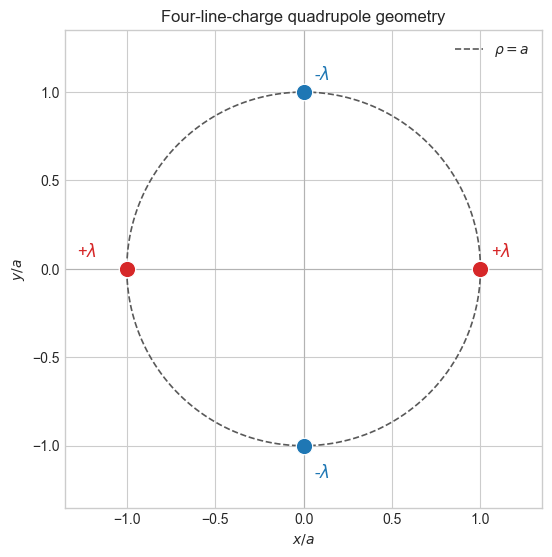

In [8]:
theta = np.linspace(0.0, 2.0 * np.pi, 600)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.plot(np.cos(theta), np.sin(theta), "--", color="0.35", lw=1.2, label=r"$\rho=a$")

for x0, y0, q, label in charge_data:
    color = "tab:red" if q > 0 else "tab:blue"
    dx = 0.06 if x0 >= 0 else -0.28
    dy = 0.07 if y0 >= 0 else -0.18
    ax.scatter(x0 / a, y0 / a, s=140, color=color, edgecolor="white", linewidth=0.9, zorder=3)
    ax.text(x0 / a + dx, y0 / a + dy, label, color=color, fontsize=12)

ax.axhline(0.0, color="0.7", lw=0.8)
ax.axvline(0.0, color="0.7", lw=0.8)
ax.set_aspect("equal")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_title("Four-line-charge quadrupole geometry")
ax.legend(loc="upper right")
plt.show()


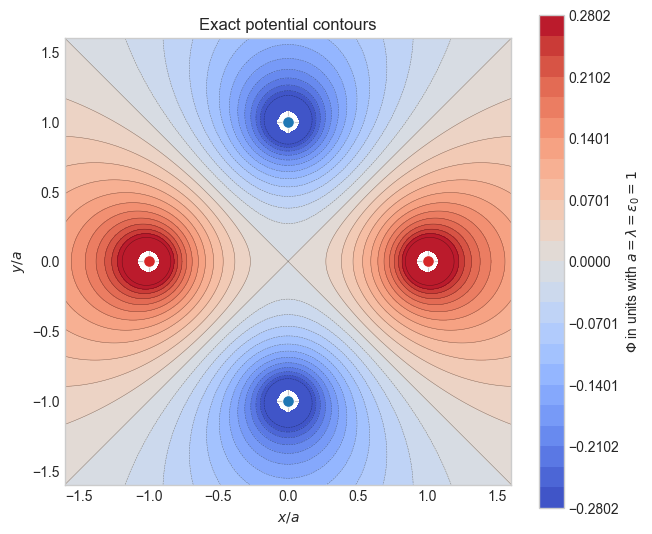

In [9]:
extent = 1.6 * a
x = np.linspace(-extent, extent, 401)
y = np.linspace(-extent, extent, 401)
X, Y = np.meshgrid(x, y)

Phi = potential_exact(X, Y, a=a, lam=lam, eps0=eps0)
mask = charge_mask(X, Y)
Phi_plot = np.ma.masked_where(mask, Phi)

vmax = np.percentile(np.abs(Phi_plot.compressed()), 97)
levels = np.linspace(-vmax, vmax, 25)

fig, ax = plt.subplots(figsize=(7.2, 6.4))
cf = ax.contourf(
    X / a,
    Y / a,
    np.ma.clip(Phi_plot, -vmax, vmax),
    levels=levels,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
)
ax.contour(X / a, Y / a, Phi_plot, levels=levels, colors="black", linewidths=0.35, alpha=0.45)

for x0, y0, q, _ in charge_data:
    color = "tab:red" if q > 0 else "tab:blue"
    ax.scatter(x0 / a, y0 / a, s=70, color=color, edgecolor="white", linewidth=0.7)

ax.set_aspect("equal")
ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_title("Exact potential contours")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$\Phi$ in units with $a=\lambda=\varepsilon_0=1$")
plt.show()


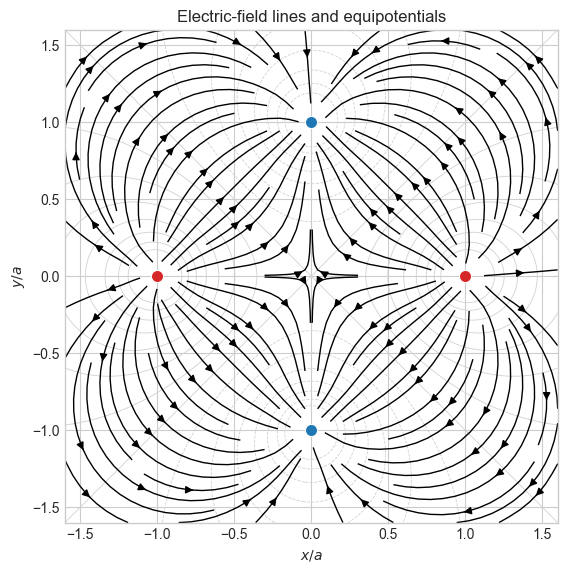

In [10]:
Ex, Ey = field_exact(X, Y, a=a, lam=lam, eps0=eps0)
cap_x = np.percentile(np.abs(Ex[~mask]), 92)
cap_y = np.percentile(np.abs(Ey[~mask]), 92)
Ex_stream = np.ma.masked_where(mask, np.clip(Ex, -cap_x, cap_x))
Ey_stream = np.ma.masked_where(mask, np.clip(Ey, -cap_y, cap_y))

fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.contour(X / a, Y / a, Phi_plot, levels=np.linspace(-vmax, vmax, 15), colors="0.82", linewidths=0.6)
ax.streamplot(x / a, y / a, Ex_stream, Ey_stream, color="black", density=1.35, linewidth=1.0, arrowsize=1.1, minlength=0.15)

for x0, y0, q, _ in charge_data:
    color = "tab:red" if q > 0 else "tab:blue"
    ax.scatter(x0 / a, y0 / a, s=75, color=color, edgecolor="white", linewidth=0.7, zorder=3)

ax.set_aspect("equal")
ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_title("Electric-field lines and equipotentials")
plt.show()


## 5. How Good Is the Pure Quadrupole Approximation?

Inside the aperture the leading field is linear in $x$ and $y$. The next correction comes from the $k=1$ term, so along the $x$ axis the relative size should grow like $(x/a)^4$.

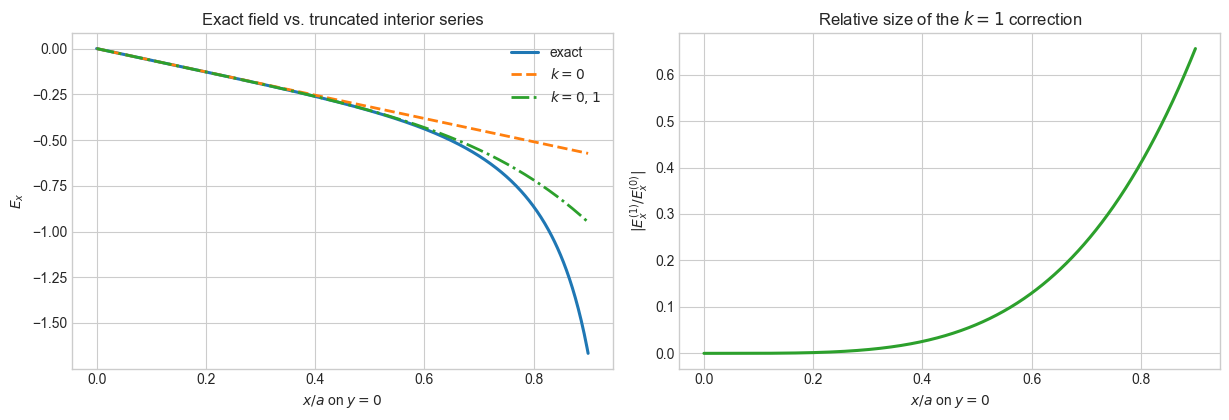

x/a = 0.2 -> |E_x^(1)/E_x^(0)| = 0.16%
x/a = 0.4 -> |E_x^(1)/E_x^(0)| = 2.56%
x/a = 0.6 -> |E_x^(1)/E_x^(0)| = 12.96%
x/a = 0.8 -> |E_x^(1)/E_x^(0)| = 40.96%


In [11]:
x_line = np.linspace(0.0, 0.9 * a, 500)
y_line = np.zeros_like(x_line)

Ex_exact_line, _ = field_exact(x_line, y_line, a=a, lam=lam, eps0=eps0)
Ex_k0_line, _ = field_inner_series(x_line, y_line, terms=1, a=a, lam=lam, eps0=eps0)
Ex_k01_line, _ = field_inner_series(x_line, y_line, terms=2, a=a, lam=lam, eps0=eps0)
ratio_formula = (x_line / a) ** 4

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

axes[0].plot(x_line / a, Ex_exact_line, lw=2.2, label="exact")
axes[0].plot(x_line / a, Ex_k0_line, "--", lw=2.0, label=r"$k=0$")
axes[0].plot(x_line / a, Ex_k01_line, "-.", lw=2.0, label=r"$k=0,1$")
axes[0].set_xlabel(r"$x/a$ on $y=0$")
axes[0].set_ylabel(r"$E_x$")
axes[0].set_title(r"Exact field vs. truncated interior series")
axes[0].legend()

axes[1].plot(x_line / a, ratio_formula, color="tab:green", lw=2.2)
axes[1].set_xlabel(r"$x/a$ on $y=0$")
axes[1].set_ylabel(r"$|E_x^{(1)}/E_x^{(0)}|$")
axes[1].set_title(r"Relative size of the $k=1$ correction")

plt.tight_layout()
plt.show()

sample_points = np.array([0.2, 0.4, 0.6, 0.8])
for value in sample_points:
    print(f"x/a = {value:.1f} -> |E_x^(1)/E_x^(0)| = {100.0 * value**4:.2f}%")


## 6. Takeaways

- The exact four-charge potential is the real part of a single logarithmic complex function.
- The symmetry removes the monopole and dipole pieces; only $m=2,6,10,\ldots$ angular harmonics remain.
- Near the origin the electric field is dominantly linear, $E_x\propto -x$ and $E_y\propto +y$, which is why the configuration acts like an electrostatic quadrupole lens.
- The first correction to that linear behavior scales as $(r/a)^4$, so the pure quadrupole picture is best well inside the aperture.